In [1]:
import json, random, csv, time, os, random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import pandas as pd
from datetime import datetime
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt
from collections import defaultdict

# Load data
with open("../stimuli/coco_caption_concereteness_with_lemmatization.json") as f:
    data = json.load(f)

for i, img in enumerate(data):
    max_score, min_score = 0, 100
    max_id, min_id = 0, 0
    for c, cap in enumerate(img['caption_concreteness']):
        mean_score = mean(cap['concreteness'])
        data[i]['caption_concreteness'][c]['concrete_score'] = mean_score
        data[i]['caption_concreteness'][c]['abstract_score'] = mean_score
        if mean_score > max_score:
            max_score = mean_score
            max_id = cap['id']
        if mean_score < min_score:
            min_score = mean_score
            min_id = cap['id']
    data[i]['concrete_abstact_diff'] = {
        'value' : max_score - min_score,
        'ids': [max_id, min_id],
}

all_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var", "abstract_score", "concrete_score"]
test_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var"]

# Filter entries with both concrete and abstract ids
filtered_data = [item for item in data if len(set(item['concrete_abstact_diff']['ids'])) > 1]
filtered_data = sorted(filtered_data, key=lambda x: x['concrete_abstact_diff']['value'], reverse=True)

def extract_attr_lists(data_subset):
    ids = []
    abs_captions = []
    con_captions = []
    value_diffs = []
    abs_vals = {attr: [] for attr in all_attributes}
    con_vals = {attr: [] for attr in all_attributes}

    for entry in data_subset:
        ids.append(entry['image'])
        value_diffs.append(entry['concrete_abstact_diff']['value'])
        con_id, abs_id = entry['concrete_abstact_diff']['ids']
        con_cap = next(c for c in entry['caption_concreteness'] if c['id'] == con_id)
        abs_cap = next(c for c in entry['caption_concreteness'] if c['id'] == abs_id)

        abs_captions.append(abs_cap)
        con_captions.append(con_cap)

        for attr in ["concrete_score", "abstract_score"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        if 'char_number' in all_attributes:
            abs_vals['char_number'].append(len(abs_cap['caption']))
            con_vals['char_number'].append(len(con_cap['caption']))

        if 'word_number' in all_attributes:
            abs_vals['word_number'].append(len(abs_cap['caption'].split(' ')))
            con_vals['word_number'].append(len(con_cap['caption'].split(' ')))

        for attr in ["matching_score", "emap_var"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        for attr in ["word_importances", "word_frequency"]:
            if attr in all_attributes:
                abs_vals[attr].append(mean(abs_cap[attr]))
                con_vals[attr].append(mean(con_cap[attr]))

    return ids, value_diffs, abs_captions, con_captions, abs_vals, con_vals

ids_all, value_diffs_all, _, _, abs_vals_all, con_vals_all = extract_attr_lists(filtered_data)

In [3]:
experiment = '20250723_193742'

## Matched

Attribute: matching_score
paired t-statistic (selected): 1.0684, p-value: 0.2886
unpaired t-statistic (selected): 0.9223, p-value: 0.3578
Attribute: word_importances
paired t-statistic (selected): 1.5545, p-value: 0.1241
unpaired t-statistic (selected): 1.3982, p-value: 0.1640
Attribute: char_number
paired t-statistic (selected): -1.3166, p-value: 0.1918
unpaired t-statistic (selected): -1.3312, p-value: 0.1850
Attribute: word_number
paired t-statistic (selected): -0.8776, p-value: 0.3828
unpaired t-statistic (selected): -0.9092, p-value: 0.3646
Attribute: word_frequency
paired t-statistic (selected): -1.5262, p-value: 0.1310
unpaired t-statistic (selected): -1.4939, p-value: 0.1372
Attribute: emap_var
paired t-statistic (selected): 0.3680, p-value: 0.7138
unpaired t-statistic (selected): 0.2035, p-value: 0.8390
Attribute: abstract_score
paired t-statistic (selected): 35.5774, p-value: 0.0000
unpaired t-statistic (selected): 35.0603, p-value: 0.0000
Attribute: concrete_score
paired t-s

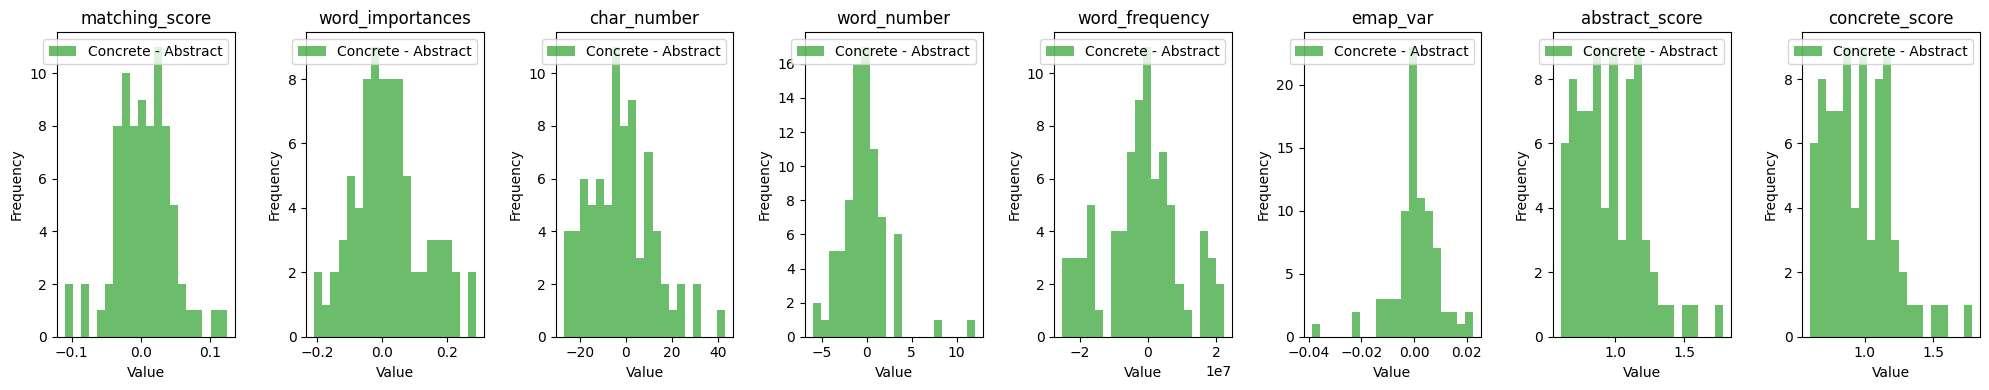

Attribute: concrete vs abstract
paired t-statistic (selected): 35.5774, p-value: 0.0000
unpaired t-statistic (selected): 35.0603, p-value: 0.0000


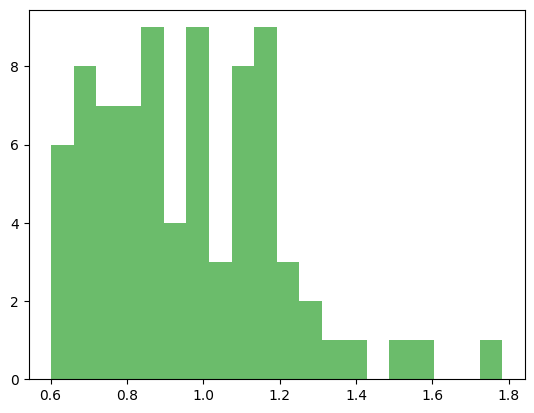

In [4]:
selected_indices = []
saved = pd.read_csv(f"/home/jinhanz/cs/concreteness/processing/stimuli_average/{experiment}/captions_and_attributes.csv")
saved_ids = saved['image_id'].tolist()
for e, entry in enumerate(filtered_data):
    if entry['image'] in saved_ids:
        selected_indices.append(e)

selected_indices.sort()
selected_entries = [filtered_data[idx] for idx in selected_indices]

ids_selected, value_diffs_selected, abs_captions_selected, con_captions_selected, abs_vals_selected, con_vals_selected = extract_attr_lists(selected_entries)

# Plot distributions for each attribute
fig, axs = plt.subplots(1, len(all_attributes), figsize=(20, 4))
for i, attr in enumerate(all_attributes):
    # Paired t-test on the selected samples
    print(f"Attribute: {attr}")
    t_stat_sel, p_value_sel = ttest_rel(con_vals_selected[attr], abs_vals_selected[attr])
    print(f"paired t-statistic (selected): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")
    t_stat_sel, p_value_sel = ttest_ind(con_vals_selected[attr], abs_vals_selected[attr])
    print(f"unpaired t-statistic (selected): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")

    axs[i].hist(np.asarray(con_vals_selected[attr]) - np.asarray((abs_vals_selected[attr])), bins=20, alpha=0.7, color="tab:green", label='Concrete - Abstract')
    axs[i].set_title(attr)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')
    axs[i].legend()

plt.tight_layout()
plt.show()

print(f"Attribute: concrete vs abstract")
t_stat_sel, p_value_sel = ttest_rel(con_vals_selected["concrete_score"], abs_vals_selected["abstract_score"])
print(f"paired t-statistic (selected): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")
t_stat_sel, p_value_sel = ttest_ind(con_vals_selected["concrete_score"], abs_vals_selected["abstract_score"])
print(f"unpaired t-statistic (selected): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")

plt.hist(np.asarray(con_vals_selected["concrete_score"]) - np.asarray((abs_vals_selected["abstract_score"])), bins=20, alpha=0.7, color="tab:green", label='Concrete - Abstract')
plt.show()

## Load mismatched data

In [5]:
ids_mismatched = [
 'val2014/COCO_val2014_000000004108.jpg',
 'val2014/COCO_val2014_000000015542.jpg',
 'val2014/COCO_val2014_000000075673.jpg',
 'val2014/COCO_val2014_000000235902.jpg',
 'val2014/COCO_val2014_000000241876.jpg',
 'val2014/COCO_val2014_000000261068.jpg',
 'val2014/COCO_val2014_000000276146.jpg',
 'val2014/COCO_val2014_000000281800.jpg',
 'val2014/COCO_val2014_000000285212.jpg',
 'val2014/COCO_val2014_000000291619.jpg',
 'val2014/COCO_val2014_000000338878.jpg',
 'val2014/COCO_val2014_000000365129.jpg',
 'val2014/COCO_val2014_000000376545.jpg',
 'val2014/COCO_val2014_000000430525.jpg',
 'val2014/COCO_val2014_000000440443.jpg',
 'val2014/COCO_val2014_000000451275.jpg',
 'val2014/COCO_val2014_000000486020.jpg',
 'val2014/COCO_val2014_000000525439.jpg',
 'val2014/COCO_val2014_000000564629.jpg',
 'val2014/COCO_val2014_000000568863.jpg',
]
random.shuffle(ids_mismatched)
for id in ids_mismatched:
    assert id not in ids_selected

In [7]:
mismatched_entries = [f for f in filtered_data if f['image'] in ids_mismatched]

ids_mismatched, value_diffs_mismatched, abs_captions_mismatched, con_captions_mismatched, abs_vals_mismatched, con_vals_mismatched = extract_attr_lists(mismatched_entries)

abs_captions_mismatched = abs_captions_mismatched[1:] + [abs_captions_mismatched[0]] #    [2,3,4,..n,1]
con_captions_mismatched = [con_captions_mismatched[-1]] + con_captions_mismatched[0:-1] # [n,1,2,3,...n-1]

## Order Randomization

In [8]:
for t in range(100):

    try: # avoid running into sampling from empty list

        matched_trials = pd.DataFrame(columns=[
            "trial_name", "sequence_number", "block_number", "match", "condition",
            "image_id", 
            "trial_id",
            "caption_text",
            "caption_char_number", 
            # "caption_coordinates" # TODO
        ])

        available_abs_ids = ids_selected.copy()
        random.shuffle(available_abs_ids)

        for b in range(1,5):
            for t in range(20):
                sample_id = random.choice(available_abs_ids)
                available_abs_ids.remove(sample_id)
                matched_trials.loc[len(matched_trials)] = {
                    "block_number": b,
                    "match": "matched",
                    "condition": "abs",
                    "image_id": sample_id,
                }

        available_con_ids = ids_selected.copy()
        random.shuffle(available_con_ids)

        for id in available_con_ids:
            abs_assignment = matched_trials[matched_trials['image_id'] == id]['block_number'].tolist()[0]
            sampling_blocks = [b for b in range(1, 5) if b != abs_assignment]
            available_blocks = sampling_blocks.copy()
            for b in sampling_blocks:
                if len(matched_trials[(matched_trials['block_number'] == b) & (matched_trials['condition'] == 'con')]) >= 20:
                    available_blocks.remove(b)

            b = random.choice(available_blocks)
            matched_trials.loc[len(matched_trials)] = {
                "block_number": b,
                "match": "matched",
                "condition": "con",
                "image_id": id,
            }

        print("Created at attempt", t)
        break

    except Exception as e:
        continue

Created at attempt 19


In [9]:
# confirm
for b in range(1, 5):
    print(f"Block {b} concrete trials: {((matched_trials['block_number'] == b) & (matched_trials['match'] == 'matched') & (matched_trials['condition'] == 'con')).sum()}")
    print(f"Block {b} abstract trials: {((matched_trials['block_number'] == b) & (matched_trials['match'] == 'matched') & (matched_trials['condition'] == 'abs')).sum()}")

# Check for duplicate image_id with both 'con' and 'abs' in the same block
for b in range(1, 5):
    block_df = matched_trials[matched_trials['block_number'] == b]
    duplicated_ids = set(
        block_df[block_df['condition'] == 'con']['image_id']
    ).intersection(
        block_df[block_df['condition'] == 'abs']['image_id']
    )
    if duplicated_ids:
        print(f"Block {b} has duplicate image_ids in both 'con' and 'abs': {duplicated_ids}")
    else:
        print(f"Block {b} passed: no image_id appears in both 'con' and 'abs'")

Block 1 concrete trials: 20
Block 1 abstract trials: 20
Block 2 concrete trials: 20
Block 2 abstract trials: 20
Block 3 concrete trials: 20
Block 3 abstract trials: 20
Block 4 concrete trials: 20
Block 4 abstract trials: 20
Block 1 passed: no image_id appears in both 'con' and 'abs'
Block 2 passed: no image_id appears in both 'con' and 'abs'
Block 3 passed: no image_id appears in both 'con' and 'abs'
Block 4 passed: no image_id appears in both 'con' and 'abs'


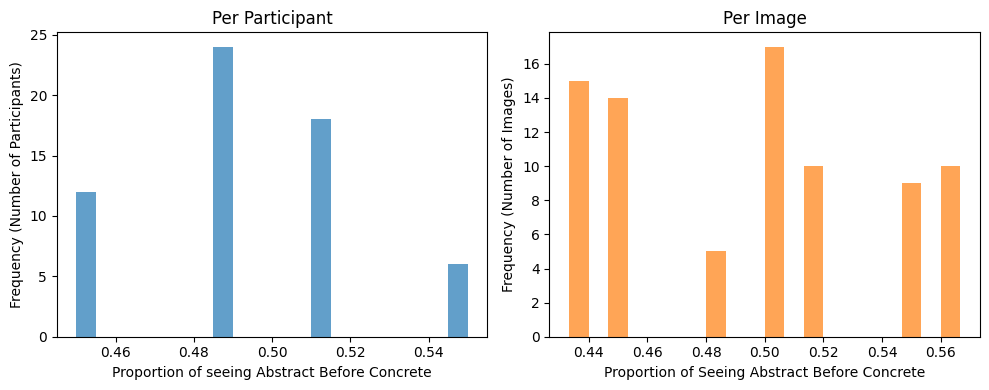

In [12]:
num_images = 80
num_participants = 60
num_blocks = 4

block_orders = []
for _ in range(num_participants):
    order = list(range(1, num_blocks + 1))
    random.shuffle(order)
    block_orders.append(order)
    
# Statistics: proportion of images per participant where abstract appears before concrete
count_per_participant = defaultdict(int)
count_per_image = defaultdict(int)
for participant_idx, order in enumerate(block_orders):
    count = 0
    for image_id in ids_selected:
        trials = matched_trials[matched_trials['image_id'] == image_id]
        abs_block = trials[trials['condition'] == 'abs']['block_number'].tolist()[0]
        con_block = trials[trials['condition'] == 'con']['block_number'].tolist()[0]

        abs_order_idx = order.index(abs_block)
        con_order_idx = order.index(con_block)
        if abs_order_idx < con_order_idx:
            count_per_image[image_id] += 1
            count += 1
    count_per_participant[participant_idx] = count

ratio_per_participant = {k: v / num_images for k, v in count_per_participant.items()}
ratio_per_image = {k: v / num_participants for k, v in count_per_image.items()}

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(list(ratio_per_participant.values()), bins=20, alpha=0.7, color='tab:blue')
plt.title('Per Participant')
plt.xlabel('Proportion of seeing Abstract Before Concrete')
plt.ylabel('Frequency (Number of Participants)')

plt.subplot(1, 2, 2)
plt.hist(list(ratio_per_image.values()), bins=20, alpha=0.7, color='tab:orange')
plt.title('Per Image')
plt.xlabel('Proportion of Seeing Abstract Before Concrete')
plt.ylabel('Frequency (Number of Images)')

plt.tight_layout()
plt.show()

In [13]:
for b in block_orders:
    print("".join([str(i) for i in b]))

# for i in range(1,61):
#     print(f"{i:03d}")

2314
2413
1234
1234
4213
2431
4132
2314
1342
2134
3124
3214
4321
2314
4123
1243
2314
3241
4231
4312
2134
4132
2314
4123
2314
4312
3421
2134
3241
4312
1234
4312
3142
3412
3214
2134
4312
3421
4312
2341
1234
4312
4132
4213
1243
4321
2413
3142
3412
2413
3124
3241
4321
3241
1234
4132
2143
1234
2413
3412


In [14]:
# Mismatched

for t in range(100):

    try: # avoid running into sampling from empty list

        mismatched_trials = pd.DataFrame(columns=[
            "trial_name", "sequence_number", "block_number", "match", "condition",
            "image_id", 
            "trial_id",
            "caption_text",
            "caption_char_number", 
            # "caption_coordinates" # TODO
        ])

        available_abs_ids = ids_mismatched.copy()
        random.shuffle(available_abs_ids)

        for b in range(1,5):
            for t in range(5):
                sample_id = random.choice(available_abs_ids)
                available_abs_ids.remove(sample_id)
                mismatched_trials.loc[len(mismatched_trials)] = {
                    "block_number": b,
                    "match": "mismatched",
                    "condition": "abs",
                    "image_id": sample_id,
                }

        available_con_ids = ids_mismatched.copy()
        random.shuffle(available_con_ids)

        for id in available_con_ids:
            abs_assignment = mismatched_trials[mismatched_trials['image_id'] == id]['block_number'].tolist()[0]
            sampling_blocks = [b for b in range(1, 5) if b != abs_assignment]
            available_blocks = sampling_blocks.copy()
            for b in sampling_blocks:
                if len(mismatched_trials[(mismatched_trials['block_number'] == b) & (mismatched_trials['condition'] == 'con')]) >= 5:
                    available_blocks.remove(b)

            b = random.choice(available_blocks)
            mismatched_trials.loc[len(mismatched_trials)] = {
                "block_number": b,
                "match": "mismatched",
                "condition": "con",
                "image_id": id,
            }

        print("Created at attempt", t)
        break

    except Exception as e:
        continue

Created at attempt 4


In [15]:
# confirm
for b in range(1, 5):
    print(f"Block {b} concrete trials: {((mismatched_trials['block_number'] == b) & (mismatched_trials['match'] == 'mismatched') & (mismatched_trials['condition'] == 'con')).sum()}")
    print(f"Block {b} abstract trials: {((mismatched_trials['block_number'] == b) & (mismatched_trials['match'] == 'mismatched') & (mismatched_trials['condition'] == 'abs')).sum()}")

# Check for duplicate image_id with both 'con' and 'abs' in the same block
for b in range(1, 5):
    block_df = mismatched_trials[mismatched_trials['block_number'] == b]
    duplicated_ids = set(
        block_df[block_df['condition'] == 'con']['image_id']
    ).intersection(
        block_df[block_df['condition'] == 'abs']['image_id']
    )
    if duplicated_ids:
        print(f"Block {b} has duplicate image_ids in both 'con' and 'abs': {duplicated_ids}")
    else:
        print(f"Block {b} passed: no image_id appears in both 'con' and 'abs'")

Block 1 concrete trials: 5
Block 1 abstract trials: 5
Block 2 concrete trials: 5
Block 2 abstract trials: 5
Block 3 concrete trials: 5
Block 3 abstract trials: 5
Block 4 concrete trials: 5
Block 4 abstract trials: 5
Block 1 passed: no image_id appears in both 'con' and 'abs'
Block 2 passed: no image_id appears in both 'con' and 'abs'
Block 3 passed: no image_id appears in both 'con' and 'abs'
Block 4 passed: no image_id appears in both 'con' and 'abs'


In [16]:
df_trials = pd.concat([matched_trials, mismatched_trials], ignore_index=True)
df_trials["image_size"] = None
df_trials["image_coordinates"] = None

In [37]:
from PIL import Image, ImageDraw, ImageFont
import csv, cv2, torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_w_all_selected = []
img_h_all_selected = []

for idx, (image_id, abs_cap, con_cap) in enumerate(zip(ids_selected+ids_mismatched, abs_captions_selected+abs_captions_mismatched, con_captions_selected+con_captions_mismatched)):
    # Load image
    img_path = f"/opt/jinhanz/data/mscoco/{image_id}"
    matchness = "matched" if image_id in ids_selected else "mismatched"
    img = Image.open(img_path)
    img = img.convert("RGB")

    # Coordinates
    center_x = 1280 // 2
    center_y = 1024 // 2

    # Caption
    text_y_start = 24*4
    frame_y_start = text_y_start + 4*24
    frame_y_end = 1024 - 24*4

    frame_size = frame_y_end - frame_y_start

    frame_x_start = 1280 // 2 - frame_size // 2
    frame_x_end = frame_x_start + frame_size

    frame_x_mid = frame_x_start + frame_size // 2
    frame_y_mid = frame_y_start + frame_size // 2

    img_w_orig, img_h_orig = img.size

    if img_w_orig > img_h_orig:
        img_w = frame_size
        img_h = int(img_h_orig * (frame_size / img_w_orig))
        coordinates = [
            frame_x_start, frame_x_end,  # left, right
            frame_y_mid-img_h//2, frame_y_mid+img_h//2,   # bottom, top
        ]
    else:
        img_h = frame_size
        img_w = int(img_w_orig * (frame_size / img_h_orig))
        coordinates = [
            frame_x_mid-img_w//2, frame_x_mid+img_w//2,   # left, right
            frame_y_start, frame_y_end,  # bottom, top
        ]

    # coordinates = [
    #         center_x - img_w//2, center_x + img_w//2,  # left, right
    #         center_y - img_h//2 , center_y + img_h//2   # top, bottom
    #     ]

    # Rescale the image up to 110%
    img = img.resize((img_w, img_h), Image.LANCZOS)

    for con, cap in zip(['abs','con'], [abs_cap, con_cap]):

        trial = df_trials[(df_trials['image_id'] == image_id) & (df_trials['condition'] == con)]
        trial_idx = trial.index[0] if not trial.empty else None
        df_trials.at[trial_idx, 'image_size'] = [img_w, img_h]
        df_trials.at[trial_idx, 'caption_text'] = cap['caption']
        df_trials.at[trial_idx, 'caption_char_number'] = len(cap['caption'])
        trial_id = f"{matchness}_{con}_{os.path.splitext(os.path.basename(image_id))[0]}.jpg"
        df_trials.at[trial_idx, 'trial_id'] = trial_id
        df_trials.at[trial_idx, 'image_coordinates'] = coordinates

        block_number = trial['block_number'].tolist()[0]

        fig, ax = plt.subplots(figsize=(12.8, 10.24), dpi=129.94923858)
        ax.set_xlim(0, 1280)
        ax.set_ylim(0, 1024)
        ax.axis('off')

        ax.text(60, text_y_start, cap['caption'], fontsize=14, color='black', va='top')

        # Rectangle at (x=30, y=20), width=40, height=25
        # rect = patches.Rectangle((frame_x_start, frame_y_start), frame_size, frame_size, linewidth=2,
        #                         edgecolor='red', facecolor='none')
        # ax.add_patch(rect)

        # ax.plot(center_x, center_y, 'ro', markersize=10)

        ax.imshow(img, extent=coordinates)

        output_dir = f"stimuli_experiment/{experiment}/{block_number}"
        os.makedirs(output_dir, exist_ok=True)

        # Save the current figure as an image file
        output_path = os.path.join(output_dir, trial_id)
        fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
        plt.close(fig)

/tmp/ipykernel_1626282/2497075176.py:57: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  img = img.resize((img_w, img_h), Image.LANCZOS)


In [39]:
df_trials = df_trials.sort_values(by="block_number").reset_index(drop=True)
df_trials.to_csv(os.path.join(f"stimuli_experiment/{experiment}", f"image_info.csv"), encoding="utf_8_sig", index=False)

## Load saved randomization instead

In [6]:
df_trials = pd.read_csv(os.path.join(f"stimuli_experiment", f"image_info_20250723_193742.csv"))

In [8]:
from PIL import Image, ImageDraw, ImageFont
import csv, cv2, torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_w_all_selected = []
img_h_all_selected = []

for trial in df_trials.itertuples():

    # Load trial info
    trial_idx = trial.Index
    image_id = trial.image_id

    con = trial.condition
    matchness = trial.match
    cap = trial.caption_text
    trial_id = trial.trial_id
    block_number = trial.block_number
    
    # Load image
    img_path = f"/opt/jinhanz/data/mscoco/{image_id}"
    img = Image.open(img_path)
    img = img.convert("RGB")

    # Coordinates
    center_x = 1280 // 2
    center_y = 1024 // 2

    # Caption
    text_y_start = 24*4
    frame_y_start = text_y_start + 4*24
    frame_y_end = 1024 - 24*4

    frame_size = frame_y_end - frame_y_start

    frame_x_start = 1280 // 2 - frame_size // 2
    frame_x_end = frame_x_start + frame_size

    frame_x_mid = frame_x_start + frame_size // 2
    frame_y_mid = frame_y_start + frame_size // 2

    img_w_orig, img_h_orig = img.size

    if img_w_orig > img_h_orig:
        img_w = frame_size
        img_h = int(img_h_orig * (frame_size / img_w_orig))
        coordinates = [
            frame_x_start, frame_x_end,  # left, right
            frame_y_mid-img_h//2, frame_y_mid+img_h//2,   # bottom, top
        ]
    else:
        img_h = frame_size
        img_w = int(img_w_orig * (frame_size / img_h_orig))
        coordinates = [
            frame_x_mid-img_w//2, frame_x_mid+img_w//2,   # left, right
            frame_y_start, frame_y_end,  # bottom, top
        ]

    # coordinates = [
    #         center_x - img_w//2, center_x + img_w//2,  # left, right
    #         center_y - img_h//2 , center_y + img_h//2   # top, bottom
    #     ]

    # Rescale the image up to 110%
    img = img.resize((img_w, img_h), Image.LANCZOS)

    # Update trial info
    df_trials.at[trial_idx, 'image_size'] = [img_w, img_h]
    df_trials.at[trial_idx, 'caption_char_number'] = len(cap)
    df_trials.at[trial_idx, 'image_coordinates'] = coordinates

    fig, ax = plt.subplots(figsize=(12.8, 10.24), dpi=129.94923858)
    ax.set_xlim(0, 1280)
    ax.set_ylim(0, 1024)
    ax.axis('off')

    ax.text(80, text_y_start, cap, fontsize=16, color='black', va='top')

    # Rectangle at (x=30, y=20), width=40, height=25
    # rect = patches.Rectangle((frame_x_start, frame_y_start), frame_size, frame_size, linewidth=2,
    #                         edgecolor='red', facecolor='none')
    # ax.add_patch(rect)

    # ax.plot(center_x, center_y, 'ro', markersize=10)

    ax.imshow(img, extent=coordinates)

    output_dir = f"stimuli_experiment/{experiment}/{block_number}"
    os.makedirs(output_dir, exist_ok=True)

    # Save the current figure as an image file
    output_path = os.path.join(output_dir, trial_id)
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)


/tmp/ipykernel_1613630/1360858718.py:67: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  img = img.resize((img_w, img_h), Image.LANCZOS)


In [9]:
df_trials = df_trials.sort_values(by="block_number").reset_index(drop=True)
df_trials.to_csv(os.path.join(f"stimuli_experiment/{experiment}", f"image_info.csv"), encoding="utf_8_sig", index=False)

## Practice

In [45]:
ids_practice = [
'val2014/COCO_val2014_000000056302.jpg',
'val2014/COCO_val2014_000000240783.jpg',
'val2014/COCO_val2014_000000296460.jpg',
'val2014/COCO_val2014_000000451084.jpg',
'val2014/COCO_val2014_000000528364.jpg'
]

In [46]:
for id in ids_practice:
    if id in ids_selected or id in ids_mismatched:
        print(f"ID {id} is in selected IDs.")

In [47]:
practice_entries = [f for f in filtered_data if f['image'] in ids_practice]

ids_practice, value_diffs_practice, abs_captions_practice, con_captions_practice, abs_vals_practice, con_vals_practice = extract_attr_lists(practice_entries)

# Change the order based on the desired indices
abs_captions_practice = [abs_captions_practice[i] for i in [0,1,4,2,3]]
con_captions_practice = [con_captions_practice[i] for i in [0,1,3,4,2]] # [n,1,2,3,...n-1]

In [48]:
from PIL import Image, ImageDraw, ImageFont
import csv, cv2, torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_w_all_selected = []
img_h_all_selected = []

for idx, (image_id, abs_cap, con_cap) in enumerate(zip(ids_practice, abs_captions_practice, con_captions_practice)):
    # Load image
    img_path = f"/opt/jinhanz/data/mscoco/{image_id}"
    matchness = "matched" if image_id in ids_practice[0:2] else "mismatched"
    img = Image.open(img_path)
    img = img.convert("RGB")

    # Coordinates
    center_x = 1280 // 2
    center_y = 1024 // 2

    # Caption
    text_y_start = 24*4
    frame_y_start = text_y_start + 4*24
    frame_y_end = 1024 - 24*4

    frame_size = frame_y_end - frame_y_start

    frame_x_start = 1280 // 2 - frame_size // 2
    frame_x_end = frame_x_start + frame_size

    frame_x_mid = frame_x_start + frame_size // 2
    frame_y_mid = frame_y_start + frame_size // 2

    img_w_orig, img_h_orig = img.size

    if img_w_orig > img_h_orig:
        img_w = frame_size
        img_h = int(img_h_orig * (frame_size / img_w_orig))
        coordinates = [
            frame_x_start, frame_x_end,  # left, right
            frame_y_mid-img_h//2, frame_y_mid+img_h//2,   # bottom, top
        ]
    else:
        img_h = frame_size
        img_w = int(img_w_orig * (frame_size / img_h_orig))
        coordinates = [
            frame_x_mid-img_w//2, frame_x_mid+img_w//2,   # left, right
            frame_y_start, frame_y_end,  # bottom, top
        ]

    # coordinates = [
    #         center_x - img_w//2, center_x + img_w//2,  # left, right
    #         center_y - img_h//2 , center_y + img_h//2   # top, bottom
    #     ]

    # Rescale the image up to 110%
    img = img.resize((img_w, img_h), Image.LANCZOS)

    for con, cap in zip(['abs','con'], [abs_cap, con_cap]):

        trial_id = f"{matchness}_{con}_{os.path.splitext(os.path.basename(image_id))[0]}.jpg"

        fig, ax = plt.subplots(figsize=(12.8, 10.24), dpi=129.94923858)
        ax.set_xlim(0, 1280)
        ax.set_ylim(0, 1024)
        ax.axis('off')

        ax.text(60, text_y_start, cap['caption'], fontsize=14, color='black', va='top')

        # Rectangle at (x=30, y=20), width=40, height=25
        # rect = patches.Rectangle((frame_x_start, frame_y_start), frame_size, frame_size, linewidth=2,
        #                         edgecolor='red', facecolor='none')
        # ax.add_patch(rect)

        # ax.plot(center_x, center_y, 'ro', markersize=10)

        ax.imshow(img, extent=coordinates)

        output_dir = f"stimuli_experiment/{experiment}/practice"
        os.makedirs(output_dir, exist_ok=True)

        # Save the current figure as an image file
        output_path = os.path.join(output_dir, trial_id)
        fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
        plt.close(fig)

/tmp/ipykernel_1626282/2879032745.py:57: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  img = img.resize((img_w, img_h), Image.LANCZOS)


## Previous

640
640


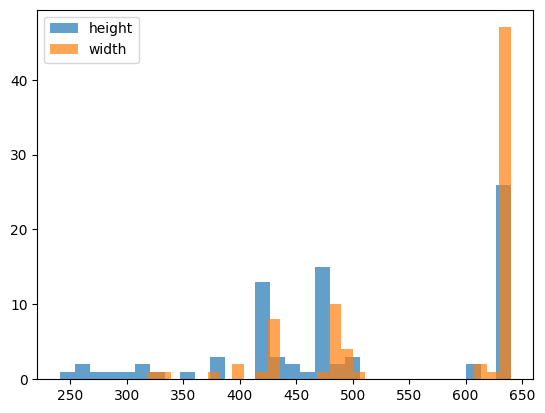

In [47]:
plt.hist(img_h_all_selected, bins=30, alpha=0.7, label='height')
plt.hist(img_w_all_selected, bins=30, alpha=0.7, label='width')
plt.legend()

print(max(img_h_all_selected))
print(max(img_w_all_selected))

## Mismatched

In [26]:
exlucded_ids = ['val2014/COCO_val2014_000000261787.jpg', # inappropriate
                'val2014/COCO_val2014_000000058462.jpg', # mispelled
                'val2014/COCO_val2014_000000053952.jpg', # incorrect
                'val2014/COCO_val2014_000000125069.jpg', # not correct
                'val2014/COCO_val2014_000000561517.jpg', # not correct
                'val2014/COCO_val2014_000000102439.jpg', # mispelled
                'val2014/COCO_val2014_000000425227.jpg', # confusing
                'val2014/COCO_val2014_000000557172.jpg',

                'val2014/COCO_val2014_000000125076.jpg', # manual check
                'val2014/COCO_val2014_000000535934.jpg',
                'val2014/COCO_val2014_000000526021.jpg',
                'val2014/COCO_val2014_000000349888.jpg',
                'val2014/COCO_val2014_000000102159.jpg',
                'val2014/COCO_val2014_000000026622.jpg',
                'val2014/COCO_val2014_000000402662.jpg',
                'val2014/COCO_val2014_000000446574.jpg',
                'val2014/COCO_val2014_000000155355.jpg',
                'val2014/COCO_val2014_000000392928.jpg',
                'val2014/COCO_val2014_000000303210.jpg',
                'val2014/COCO_val2014_000000226579.jpg',
                'val2014/COCO_val2014_000000172079.jpg',
                'val2014/COCO_val2014_000000498596.jpg',
                'val2014/COCO_val2014_000000505169.jpg',
                'val2014/COCO_val2014_000000455315.jpg',
                'val2014/COCO_val2014_000000359314.jpg',
                'val2014/COCO_val2014_000000289900.jpg',
                'val2014/COCO_val2014_000000335670.jpg',
                'val2014/COCO_val2014_000000054092.jpg',
                'val2014/COCO_val2014_000000226069.jpg',
                'val2014/COCO_val2014_000000268247.jpg',
                'val2014/COCO_val2014_000000476841.jpg',
                'val2014/COCO_val2014_000000044022.jpg',
                'val2014/COCO_val2014_000000093476.jpg',
                'val2014/COCO_val2014_000000001464.jpg',
                'val2014/COCO_val2014_000000077951.jpg',
                'val2014/COCO_val2014_000000265719.jpg',
                'val2014/COCO_val2014_000000081248.jpg',
                'val2014/COCO_val2014_000000071826.jpg',
                'val2014/COCO_val2014_000000195862.jpg',
                'val2014/COCO_val2014_000000361430.jpg',
                'val2014/COCO_val2014_000000149780.jpg',
                'val2014/COCO_val2014_000000576774.jpg',
                'val2014/COCO_val2014_000000113251.jpg',
                'val2014/COCO_val2014_000000279279.jpg',
                'val2014/COCO_val2014_000000533137.jpg',
                'val2014/COCO_val2014_000000204757.jpg',
                'val2014/COCO_val2014_000000207108.jpg',
                'val2014/COCO_val2014_000000553081.jpg',
                'val2014/COCO_val2014_000000034167.jpg',
                'val2014/COCO_val2014_000000052982.jpg',
                'val2014/COCO_val2014_000000193121.jpg',
                'val2014/COCO_val2014_000000235241.jpg',
                'val2014/COCO_val2014_000000579438.jpg',
                'val2014/COCO_val2014_000000158222.jpg',
                'val2014/COCO_val2014_000000412639.jpg',
                'val2014/COCO_val2014_000000435387.jpg',
                'val2014/COCO_val2014_000000231855.jpg',
                'val2014/COCO_val2014_000000089670.jpg',
                'val2014/COCO_val2014_000000434990.jpg',
                'val2014/COCO_val2014_000000282591.jpg',
                'val2014/COCO_val2014_000000538775.jpg',
                'val2014/COCO_val2014_000000218060.jpg',
                'val2014/COCO_val2014_000000570594.jpg',
                'val2014/COCO_val2014_000000413709.jpg',
                'val2014/COCO_val2014_000000094317.jpg',
                'val2014/COCO_val2014_000000025138.jpg',
                'val2014/COCO_val2014_000000036414.jpg',
                'val2014/COCO_val2014_000000489346.jpg',
                'val2014/COCO_val2014_000000051984.jpg',
                'val2014/COCO_val2014_000000507361.jpg',
                'val2014/COCO_val2014_000000233834.jpg',
                'val2014/COCO_val2014_000000202609.jpg',
                'val2014/COCO_val2014_000000413522.jpg',
                'val2014/COCO_val2014_000000499571.jpg',
                'val2014/COCO_val2014_000000436130.jpg',
                'val2014/COCO_val2014_000000274931.jpg',
                'val2014/COCO_val2014_000000578813.jpg',
                'val2014/COCO_val2014_000000239235.jpg',
                'val2014/COCO_val2014_000000480652.jpg',
                'val2014/COCO_val2014_000000107257.jpg',
                'val2014/COCO_val2014_000000199688.jpg',
                'val2014/COCO_val2014_000000092804.jpg',
                'val2014/COCO_val2014_000000397427.jpg',
                'val2014/COCO_val2014_000000396556.jpg',
                'val2014/COCO_val2014_000000064574.jpg',
                'val2014/COCO_val2014_000000464633.jpg',
                'val2014/COCO_val2014_000000382758.jpg',
                'val2014/COCO_val2014_000000006810.jpg',
                'val2014/COCO_val2014_000000442210.jpg',
                'val2014/COCO_val2014_000000000474.jpg',
                'val2014/COCO_val2014_000000079408.jpg',
                'val2014/COCO_val2014_000000005728.jpg',
                'val2014/COCO_val2014_000000446285.jpg',
                'val2014/COCO_val2014_000000040275.jpg',
                'val2014/COCO_val2014_000000177258.jpg',
                'val2014/COCO_val2014_000000159223.jpg',
                'val2014/COCO_val2014_000000313718.jpg',
                'val2014/COCO_val2014_000000104691.jpg',
                'val2014/COCO_val2014_000000384794.jpg',
                'val2014/COCO_val2014_000000550432.jpg',
                'val2014/COCO_val2014_000000566436.jpg',
                ]

In [27]:
from scipy.stats import ttest_rel
import random

preserved_indices = []

attr = "char_number"
print(f"Attribute: {attr}")
t_stat, p_value = ttest_rel(con_vals_all[attr], abs_vals_all[attr])
print(f"(All) t-statistic: {t_stat}, p-value: {p_value}")
all_diff = np.asarray(con_vals_all[attr]) - np.asarray((abs_vals_all[attr]))
selected_indices_temp = [
    idx for idx, diff in enumerate(all_diff)
    if con_vals_all[attr][idx] <= 100 and abs_vals_all[attr][idx] <= 100 # hand-picked
]
print(len(selected_indices_temp))
preserved_indices = list(set(preserved_indices) & set(selected_indices_temp)) if preserved_indices else selected_indices_temp

preserved_indices = list(set(preserved_indices) - set([filtered_data.index(item) for item in filtered_data if item['image'] in exlucded_ids]) - set(selected_indices))

print(f"Final set: {len(preserved_indices)}")

preserved_indices.sort()

Attribute: char_number
(All) t-statistic: -13.033986105183725, p-value: 3.271818849618711e-38
4937
Final set: 4756


In [30]:
mismatched_indices = random.sample(preserved_indices, 5)

mismatched_entries = [filtered_data[idx] for idx in mismatched_indices]

ids_mismatched, value_diffs_mismatched, abs_captions_mismatched, con_captions_mismatched, abs_vals_mismatched, con_vals_mismatched = extract_attr_lists(mismatched_entries)

# Change the order based on the desired indices
abs_captions_mismatched = [abs_captions_mismatched[i] for i in [0,1,4,2,3]]
con_captions_mismatched = [con_captions_mismatched[i] for i in [0,1,3,4,2]] # [n,1,2,3,...n-1]

In [31]:
ids_mismatched

['val2014/COCO_val2014_000000451084.jpg',
 'val2014/COCO_val2014_000000528364.jpg',
 'val2014/COCO_val2014_000000056302.jpg',
 'val2014/COCO_val2014_000000240783.jpg',
 'val2014/COCO_val2014_000000296460.jpg']

/tmp/ipykernel_1189197/1046882236.py:58: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  img = img.resize((img_w, img_h), Image.LANCZOS)


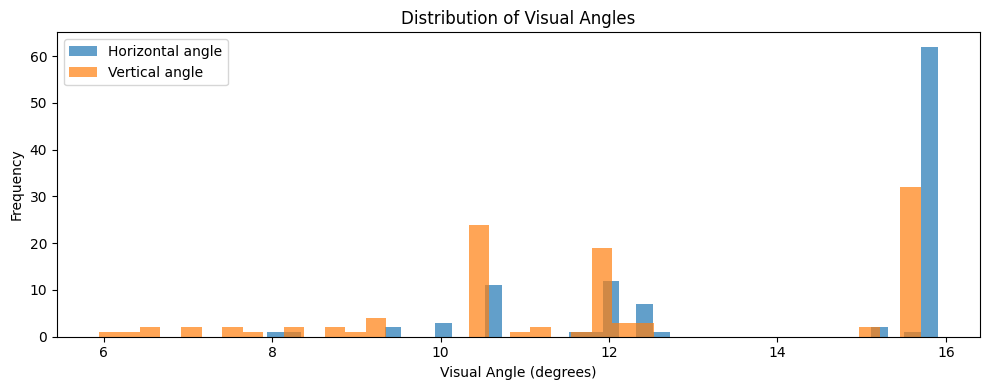

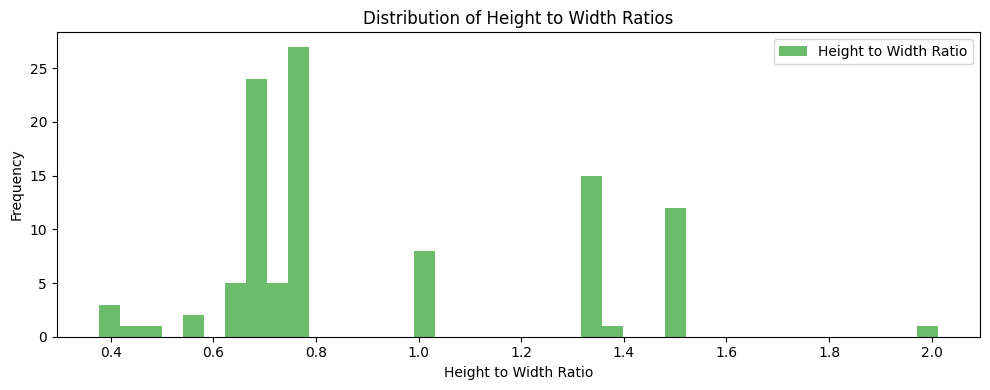

In [59]:
import math

def compute_visual_angle(
    screen_width_px, screen_height_px,
    screen_width_cm, screen_height_cm,
    image_width_px, image_height_px,
    eye_distance_cm
):
    # Step 1: pixels per cm
    pixels_per_cm_x = screen_width_px / screen_width_cm
    pixels_per_cm_y = screen_height_px / screen_height_cm

    # Step 2: image size in cm
    image_width_cm = image_width_px / pixels_per_cm_x
    image_height_cm = image_height_px / pixels_per_cm_y

    # Step 3: visual angle in degrees
    theta_horizontal = 2 * math.degrees(math.atan((image_width_cm / 2) / eye_distance_cm))
    theta_vertical = 2 * math.degrees(math.atan((image_height_cm / 2) / eye_distance_cm))

    return theta_horizontal, theta_vertical

# Example usage
screen_w_px = 1280
screen_h_px = 1024
screen_w_mm = 380
screen_h_mm = 300
eye_dist_mm = 680

horizontal_angle_all = []
vertical_angle_all = []
h_to_w_ratio_all = []

for image_w_px, image_h_px in zip(img_w_all_selected+img_w_all_mismatched, img_h_all_selected+img_h_all_mismatched):

    horizontal_angle, vertical_angle = compute_visual_angle(
        screen_w_px, screen_h_px,
        screen_w_mm, screen_h_mm,
        image_w_px, image_h_px,
        eye_dist_mm
    )

    horizontal_angle_all.append(horizontal_angle)
    vertical_angle_all.append(vertical_angle)
    h_to_w_ratio_all.append(image_h_px / image_w_px)

plt.figure(figsize=(10, 4))
plt.hist(horizontal_angle_all, bins=40, alpha=0.7, label='Horizontal angle')
plt.hist(vertical_angle_all, bins=40, alpha=0.7, label='Vertical angle')
plt.xlabel('Visual Angle (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Visual Angles')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(h_to_w_ratio_all, bins=40, alpha=0.7, color="tab:green", label='Height to Width Ratio')
plt.xlabel('Height to Width Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Height to Width Ratios')
plt.tight_layout()
plt.show()